# Metaphorical Usage as Contextual Embedding Shift: MVP Experiment

This notebook implements a small proof-of-concept experiment for the hypothesis:

> **Do metaphorical uses of a verb occur farther away from its literal-use centroid in contextual embedding space?**

Operational definition:

$
Enc(x,t)=\text{contextual embedding of target token }t\text{ in sentence }x
$

The encoder is `roberta-base`. If the target word is split into multiple subword tokens, the target representation is the average of those subword vectors. The main distance measure is cosine distance after L2 normalization.

The experiment uses the VUA20 metaphor dataset, filters to `POS = VERB`, samples up to 200 lemmas that have both literal and metaphorical examples, and runs:

1. **literal centroid distance**
2. **literal vs. metaphor centroid separation**
3. **embedding + Logistic Regression / Linear SVM baseline**
4. **anisotropy diagnostics and robustness checks**

## 0. Install environment

Run this cell first in Google Colab. Runtime recommendation: **GPU**.

In [1]:
!pip -q install datasets transformers accelerate scikit-learn scipy pandas numpy matplotlib tqdm nltk

## 1. Imports and global configuration

The parameters below are intentionally small enough for a course-project MVP. Increase `N_LEMMAS` or `MAX_PER_LABEL_PER_LEMMA` only after the pipeline runs successfully.

In [2]:
import os
import random
import math
import warnings
from collections import Counter, defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
from tqdm.auto import tqdm
from datasets import load_dataset

from transformers import AutoTokenizer, AutoModel

from sklearn.decomposition import PCA
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

from scipy.spatial.distance import cosine
from scipy.stats import ttest_ind, mannwhitneyu, pointbiserialr, spearmanr, pearsonr, wilcoxon

import nltk
nltk.download("wordnet")
from nltk.stem import WordNetLemmatizer

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DATASET_NAME = "CreativeLang/vua20_metaphor"
MODEL_NAME = "roberta-base"

POS_FILTER = "VERB"
N_LEMMAS = 200
MAX_PER_LABEL_PER_LEMMA = 8
MAX_LENGTH = 128
BATCH_SIZE = 32

OUTPUT_DIR = "/content/metaphor_mvp_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

[nltk_data] Downloading package wordnet to /root/nltk_data...


Device: cuda


## 2. Load VUA20

The Hugging Face version is used here because it is convenient for Colab. The next cells inspect the column names and infer the sentence, POS, target-index, and label columns.

If the dataset schema changes, the diagnostic printout helps you adjust the candidate column names in the helper functions.

In [3]:
ds = load_dataset(DATASET_NAME)
print(ds)

dfs = []
for split_name, split_ds in ds.items():
    tmp = split_ds.to_pandas()
    tmp["split"] = split_name
    dfs.append(tmp)

df_raw = pd.concat(dfs, ignore_index=True)
print("Rows:", len(df_raw))
print("Columns:", list(df_raw.columns))
display(df_raw.head())

README.md:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

train.tsv:   0%|          | 0.00/28.5M [00:00<?, ?B/s]

test.tsv:   0%|          | 0.00/4.01M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/160154 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/22196 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['index', 'label', 'sentence', 'POS', 'FGPOS', 'w_index'],
        num_rows: 160154
    })
    test: Dataset({
        features: ['index', 'label', 'sentence', 'POS', 'FGPOS', 'w_index'],
        num_rows: 22196
    })
})
Rows: 182350
Columns: ['index', 'label', 'sentence', 'POS', 'FGPOS', 'w_index', 'split']


,index,label,sentence,POS,FGPOS,w_index,split
0,a1e-fragment01 1,0,Latest corporate unbundler reveals laid-back a...,ADJ,JJS,0,train
1,a1e-fragment01 1,0,Latest corporate unbundler reveals laid-back a...,ADJ,JJ,1,train
2,a1e-fragment01 1,0,Latest corporate unbundler reveals laid-back a...,PROPN,NNP,2,train
3,a1e-fragment01 1,1,Latest corporate unbundler reveals laid-back a...,VERB,VBZ,3,train
4,a1e-fragment01 1,0,Latest corporate unbundler reveals laid-back a...,VERB,VBN,4,train


## 3. Infer columns and normalize labels

Expected fields are:

- sentence / text
- POS tag
- target token index
- metaphor label

The code is written defensively because public dataset wrappers sometimes use slightly different column names.

In [11]:
def find_col(columns, candidates, required=True):
    lower_map = {c.lower(): c for c in columns}
    for cand in candidates:
        if cand.lower() in lower_map:
            return lower_map[cand.lower()]
    for col in columns:
        low = col.lower()
        if any(cand.lower() in low for cand in candidates):
            return col
    if required:
        raise ValueError(f"Could not find a column among candidates: {candidates}")
    return None

columns = list(df_raw.columns)

sentence_col = find_col(columns, ["sentence", "sent", "text", "context"])
pos_col = find_col(columns, ["pos", "upos", "universal_pos"], required=False)
xpos_col = find_col(columns, ["xpos", "tag", "ptb", "pos_tag"], required=False)
idx_col = find_col(columns, ["w_index", "word_index", "idx", "token_index", "position", "target_position", "index"])
label_col = find_col(columns, ["label", "metaphor", "is_metaphor", "metaphorical"])
word_col = find_col(columns, ["word", "token", "target", "target_word"], required=False)
lemma_col = find_col(columns, ["lemma"], required=False)

print("sentence_col:", sentence_col)
print("pos_col:", pos_col)
print("xpos_col:", xpos_col)
print("idx_col:", idx_col)
print("label_col:", label_col)
print("word_col:", word_col)
print("lemma_col:", lemma_col)

def to_binary_label(v):
    if pd.isna(v):
        return np.nan
    if isinstance(v, (int, np.integer, float, np.floating)):
        return int(v)
    s = str(v).strip().lower()
    if s in {"1", "true", "yes", "y", "metaphor", "metaphorical", "m"}:
        return 1
    if s in {"0", "false", "no", "n", "literal", "nonmetaphor", "non-metaphor", "l"}:
        return 0
    try:
        return int(float(s))
    except Exception:
        return np.nan

df = df_raw.copy()
df["label_bin"] = df[label_col].apply(to_binary_label)
print(df["label_bin"].value_counts(dropna=False))

sentence_col: sentence
pos_col: POS
xpos_col: None
idx_col: w_index
label_col: label
word_col: None
lemma_col: None
label_bin
0    159197
1     23153
Name: count, dtype: int64


## 4. Filter to verb targets and construct target lemmas

This MVP focuses only on **verb metaphors**. If no lemma column is provided, the lemma is approximated with WordNet's verb lemmatizer from the target word.

The target word is recovered from the whitespace-tokenized sentence using the dataset's target token index.

In [12]:
lemmatizer = WordNetLemmatizer()

def get_tokens(sentence):
    return str(sentence).split()

def safe_int(x):
    try:
        return int(x)
    except Exception:
        return None

def get_target_word(row):
    if word_col is not None and pd.notna(row[word_col]):
        return str(row[word_col])
    toks = get_tokens(row[sentence_col])
    idx = safe_int(row[idx_col])
    if idx is None or idx < 0 or idx >= len(toks):
        return None
    return toks[idx]

def is_verb(row):
    vals = []
    if pos_col is not None:
        vals.append(str(row[pos_col]).upper())
    if xpos_col is not None:
        vals.append(str(row[xpos_col]).upper())
    return ("VERB" in vals) or any(v.startswith("VB") for v in vals)

df["is_verb"] = df.apply(is_verb, axis=1)
df["target_idx"] = df[idx_col].apply(safe_int)
df["tokens"] = df[sentence_col].apply(get_tokens)
df["target_word"] = df.apply(get_target_word, axis=1)

if lemma_col is not None:
    df["lemma"] = df[lemma_col].astype(str).str.lower()
else:
    df["lemma"] = df["target_word"].astype(str).str.lower().apply(lambda w: lemmatizer.lemmatize(w, "v"))

df_verb = df[
    (df["is_verb"]) &
    (df["label_bin"].isin([0, 1])) &
    (df["target_word"].notna()) &
    (df["target_idx"].notna())
].copy()

df_verb = df_verb[df_verb.apply(lambda r: 0 <= int(r["target_idx"]) < len(r["tokens"]), axis=1)].copy()

print("Verb rows:", len(df_verb))
print(df_verb["label_bin"].value_counts())
display(df_verb[[sentence_col, "target_word", "lemma", "target_idx", "label_bin"]].head())

Verb rows: 24930
label_bin
0    18703
1     6227
Name: count, dtype: int64


,sentence,target_word,lemma,target_idx,label_bin
3,Latest corporate unbundler reveals laid-back a...,reveals,reveal,3,1
4,Latest corporate unbundler reveals laid-back a...,laid-back,laid-back,4,0
10,Latest corporate unbundler reveals laid-back a...,leading,lead,12,1
34,"IT SEEMS that Roland Franklin , the latest unb...",appear,appear,10,0
39,"IT SEEMS that Roland Franklin , the latest unb...",made,make,16,1


## 5. Sample 200 lemmas with both literal and metaphorical examples

To avoid high-frequency lemmas dominating the result, each lemma contributes at most `MAX_PER_LABEL_PER_LEMMA` literal examples and the same number of metaphorical examples.

In [13]:
label_counts_by_lemma = df_verb.groupby(["lemma", "label_bin"]).size().unstack(fill_value=0)

# Check if label_counts_by_lemma is empty before attempting to filter
if not label_counts_by_lemma.empty:
    eligible_lemmas = label_counts_by_lemma[(label_counts_by_lemma.get(0, 0) > 0) & (label_counts_by_lemma.get(1, 0) > 0)].index.tolist()
elif 0 in label_counts_by_lemma.columns and 1 in label_counts_by_lemma.columns: # Fallback in case unstack returns columns but no rows
    eligible_lemmas = label_counts_by_lemma[(label_counts_by_lemma[0] > 0) & (label_counts_by_lemma[1] > 0)].index.tolist()
else:
    eligible_lemmas = [] # Initialize as an empty list if no lemmas are eligible or columns are missing

print("Eligible lemmas with both labels:", len(eligible_lemmas))
random.shuffle(eligible_lemmas)
selected_lemmas = eligible_lemmas[:min(N_LEMMAS, len(eligible_lemmas))]
print("Selected lemmas:", len(selected_lemmas))

sample_parts = []
for lemma in selected_lemmas:
    sub = df_verb[df_verb["lemma"] == lemma]
    for label in [0, 1]:
        sub_label = sub[sub["label_bin"] == label]
        n = min(MAX_PER_LABEL_PER_LEMMA, len(sub_label))
        sample_parts.append(sub_label.sample(n=n, random_state=SEED))

# Fix: Check if sample_parts is empty before concatenation
if sample_parts:
    df_sample = pd.concat(sample_parts, ignore_index=True).sample(frac=1, random_state=SEED).reset_index(drop=True)
else:
    # Create an empty DataFrame with the expected columns if no samples were collected.
    # This assumes df_verb.columns correctly represents the structure.
    df_sample = pd.DataFrame(columns=df_verb.columns)

df_sample["sent_len"] = df_sample["tokens"].apply(len)
df_sample["lemma_freq_in_sample"] = df_sample.groupby("lemma")["lemma"].transform("size")

print("Sample rows:", len(df_sample))
print("Lemmas:", df_sample["lemma"].nunique())
display(pd.crosstab(df_sample["label_bin"], columns="count"))
display(df_sample[[sentence_col, "tokens", "target_word", "lemma", "target_idx", "label_bin"]].head())

df_sample.to_csv(os.path.join(OUTPUT_DIR, "sampled_vua20_verbs.csv"), index=False)

Eligible lemmas with both labels: 784
Selected lemmas: 200
Sample rows: 1605
Lemmas: 200


col_0,count
label_bin,
0,898
1,707


,sentence,tokens,target_word,lemma,target_idx,label_bin
0,"High arched walls of pale , honey-coloured sto...","[High, arched, walls, of, pale, ,, honey-colou...",covered,cover,28,0
1,There are important analytical problems to be ...,"[There, are, important, analytical, problems, ...",addressed,address,7,0
2,"After they 'd gone , Forster felt the silence ...","[After, they, 'd, gone, ,, Forster, felt, the,...",settle,settle,10,1
3,The Labour Party Conference : Policy review th...,"[The, Labour, Party, Conference, :, Policy, re...",throws,throw,7,1
4,"‘ Do n't leave me , ’ she begged .","[‘, Do, n't, leave, me, ,, ’, she, begged, .]",begged,beg,8,0


## 6. Dataset statistics plot

This table and plot become **Table 1 / Figure 1** candidates in the final report.

,n_rows,n_lemmas,literal,metaphorical,mean_sentence_length,max_per_label_per_lemma
0,1605,200,898,707,28.761371,8


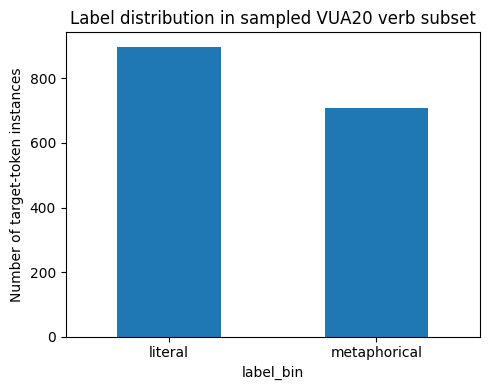

In [14]:
stats = pd.DataFrame({
    "n_rows": [len(df_sample)],
    "n_lemmas": [df_sample["lemma"].nunique()],
    "literal": [(df_sample["label_bin"] == 0).sum()],
    "metaphorical": [(df_sample["label_bin"] == 1).sum()],
    "mean_sentence_length": [df_sample["sent_len"].mean()],
    "max_per_label_per_lemma": [MAX_PER_LABEL_PER_LEMMA],
})
display(stats)

plt.figure(figsize=(5,4))
df_sample["label_bin"].map({0:"literal", 1:"metaphorical"}).value_counts().plot(kind="bar")
plt.title("Label distribution in sampled VUA20 verb subset")
plt.ylabel("Number of target-token instances")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "label_distribution.png"), dpi=200)
plt.show()

## 7. Extract target-token contextual embeddings from RoBERTa

For each target word, all RoBERTa subword vectors corresponding to the target whitespace token are averaged.

This implements:

$
Enc(x,t)=\text{mean of RoBERTa subword vectors for target token }t\text{ in }x
$

In [15]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=True)
model = AutoModel.from_pretrained(MODEL_NAME).to(device)
model.eval()

def extract_target_embeddings(df_in, batch_size=BATCH_SIZE):
    vectors = []
    subword_counts = []
    skipped = []

    records = df_in.reset_index(drop=True).to_dict("records")

    for start in tqdm(range(0, len(records), batch_size)):
        batch = records[start:start+batch_size]
        batch_tokens = [r["tokens"] for r in batch]
        batch_indices = [int(r["target_idx"]) for r in batch]

        enc = tokenizer(
            batch_tokens,
            is_split_into_words=True,
            return_tensors="pt",
            padding=True,
            truncation=True,
            max_length=MAX_LENGTH,
        ).to(device)

        with torch.no_grad():
            out = model(**enc)
            hidden = out.last_hidden_state.detach().cpu()

        for i, target_idx in enumerate(batch_indices):
            word_ids = enc.word_ids(batch_index=i)
            positions = [j for j, wid in enumerate(word_ids) if wid == target_idx]
            if not positions:
                vectors.append(None)
                subword_counts.append(0)
                skipped.append(start+i)
                continue
            vec = hidden[i, positions, :].mean(dim=0).numpy()
            vectors.append(vec)
            subword_counts.append(len(positions))

    return vectors, subword_counts, skipped

vectors, subword_counts, skipped = extract_target_embeddings(df_sample)
df_sample["subword_count"] = subword_counts
df_sample["embedding_ok"] = [v is not None for v in vectors]

df_embed = df_sample[df_sample["embedding_ok"]].reset_index(drop=True).copy()
X_raw = np.vstack([v for v in vectors if v is not None]).astype(np.float32)

print("Embedding matrix:", X_raw.shape)
print("Skipped rows:", len(skipped))
display(df_embed[["target_word", "lemma", "target_idx", "subword_count", "label_bin"]].head())

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: roberta-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.bias        | UNEXPECTED | 
lm_head.dense.weight      | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  0%|          | 0/51 [00:00<?, ?it/s]

Embedding matrix: (1605, 768)
Skipped rows: 0


,target_word,lemma,target_idx,subword_count,label_bin
0,covered,cover,28,1,0
1,addressed,address,7,2,0
2,settle,settle,10,2,1
3,throws,throw,7,2,1
4,begged,beg,8,2,0


## 8. Vector processing: L2 normalization, mean-centering, and top-PC removal

The main distance analysis uses L2-normalized embeddings. Mean-centering is added to reduce a common direction. Top-PC removal is included as an optional robustness check.

In [16]:
def l2_normalize(X, eps=1e-12):
    return X / np.maximum(np.linalg.norm(X, axis=1, keepdims=True), eps)

def mean_center_then_l2(X):
    return l2_normalize(X - X.mean(axis=0, keepdims=True))

def remove_top_pcs_then_l2(X, n_remove=1):
    Xc = X - X.mean(axis=0, keepdims=True)
    pca = PCA(n_components=min(n_remove, Xc.shape[1], Xc.shape[0]-1), random_state=SEED)
    comps = pca.fit(Xc).components_
    X_removed = Xc - Xc @ comps.T @ comps
    return l2_normalize(X_removed)

X_l2 = l2_normalize(X_raw)
X_center_l2 = mean_center_then_l2(X_raw)
X_pc1_l2 = remove_top_pcs_then_l2(X_raw, n_remove=1)

vector_settings = {
    "L2": X_l2,
    "Mean-centered + L2": X_center_l2,
    "Remove PC1 + L2": X_pc1_l2,
}

## 9. Anisotropy diagnostics

Two simple anisotropy indicators are used:

1. **mean random-pair cosine similarity**: higher positive mean means stronger global directional concentration;
2. **PC1 variance ratio**: higher value means one dominant direction explains more variance.

The normalized score below maps mean cosine from `[-1, 1]` to `[0, 1]` only to make interpretation easier.

,setting,mean_pairwise_cosine,std_pairwise_cosine,anisotropy_0_1,pc1_variance_ratio,effective_rank_top10
0,Raw,0.857042,0.033543,0.928521,0.075934,2.801059
1,L2,0.857042,0.033543,0.928521,0.074209,2.728884
2,Mean-centered + L2,0.001633,0.120707,0.500817,0.070083,2.777591
3,Remove PC1 + L2,0.000704,0.105266,0.500352,0.046570,2.562710


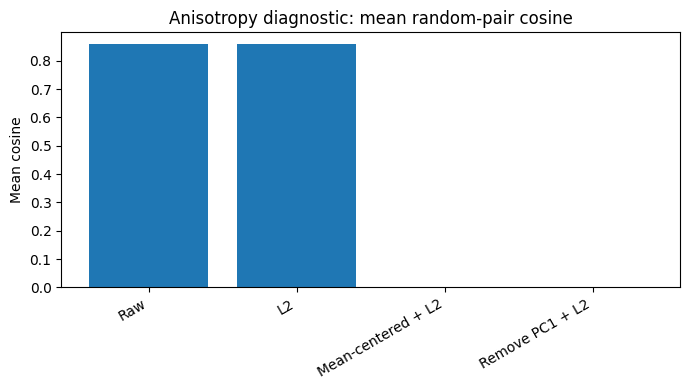

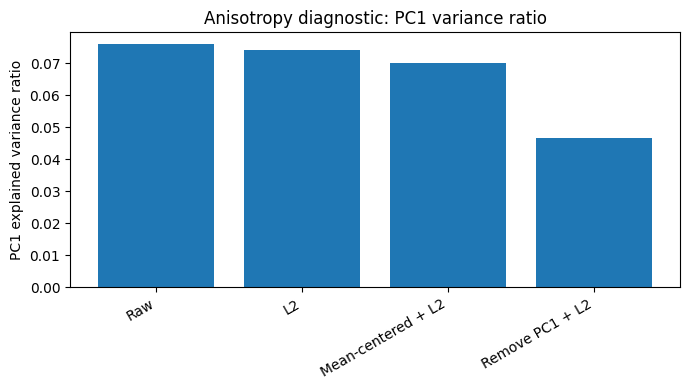

In [17]:
def anisotropy_metrics(X, n_pairs=20000):
    Xn = l2_normalize(X)
    n = len(Xn)
    rng = np.random.default_rng(SEED)
    i = rng.integers(0, n, size=min(n_pairs, n*n))
    j = rng.integers(0, n, size=min(n_pairs, n*n))
    mask = i != j
    cos_vals = np.sum(Xn[i[mask]] * Xn[j[mask]], axis=1)

    pca = PCA(n_components=min(10, X.shape[0]-1, X.shape[1]), random_state=SEED)
    pca.fit(X - X.mean(axis=0, keepdims=True))
    evr = pca.explained_variance_ratio_
    effective_rank = float(np.exp(-np.sum(evr * np.log(evr + 1e-12))))

    return {
        "mean_pairwise_cosine": float(np.mean(cos_vals)),
        "std_pairwise_cosine": float(np.std(cos_vals)),
        "anisotropy_0_1": float((np.mean(cos_vals) + 1) / 2),
        "pc1_variance_ratio": float(evr[0]),
        "effective_rank_top10": effective_rank,
    }

anis_rows = []
for name, X in {"Raw": X_raw, **vector_settings}.items():
    row = {"setting": name}
    row.update(anisotropy_metrics(X))
    anis_rows.append(row)

anis_df = pd.DataFrame(anis_rows)
display(anis_df)

plt.figure(figsize=(7,4))
plt.bar(anis_df["setting"], anis_df["mean_pairwise_cosine"])
plt.title("Anisotropy diagnostic: mean random-pair cosine")
plt.ylabel("Mean cosine")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "anisotropy_mean_cosine.png"), dpi=200)
plt.show()

plt.figure(figsize=(7,4))
plt.bar(anis_df["setting"], anis_df["pc1_variance_ratio"])
plt.title("Anisotropy diagnostic: PC1 variance ratio")
plt.ylabel("PC1 explained variance ratio")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "anisotropy_pc1.png"), dpi=200)
plt.show()

anis_df.to_csv(os.path.join(OUTPUT_DIR, "anisotropy_metrics.csv"), index=False)

## 10. Check possible factors behind anisotropy

If anisotropy is visible, inspect whether the dominant direction correlates with simple non-semantic factors:

- sentence length
- subword count
- lemma frequency
- metaphor label

This does not fully solve anisotropy, but it makes the risk explicit.

,factor,correlation_with_pc1,p_value,correlation_type
0,sent_len,-0.291635,7.784535e-33,spearman
1,subword_count,-0.463717,2.265959e-86,spearman
2,lemma_freq_in_sample,0.115121,3.767589e-06,spearman
3,label_bin,-0.028821,2.485025e-01,pearson


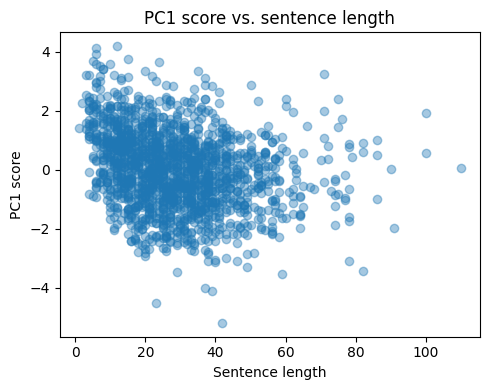

<Figure size 500x400 with 0 Axes>

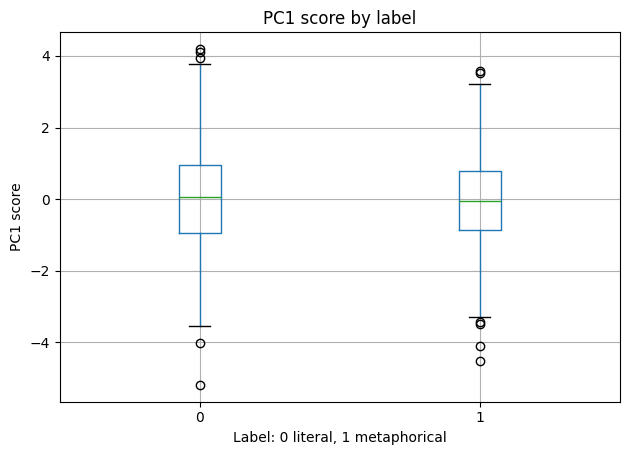

In [18]:
pca_raw = PCA(n_components=3, random_state=SEED)
pc_scores = pca_raw.fit_transform(X_raw - X_raw.mean(axis=0, keepdims=True))
df_embed["pc1_score"] = pc_scores[:, 0]
df_embed["pc2_score"] = pc_scores[:, 1]

factor_rows = []

def safe_corr(x, y, kind="pearson"):
    try:
        if kind == "spearman":
            r, p = spearmanr(x, y)
        else:
            r, p = pearsonr(x, y)
        return float(r), float(p)
    except Exception:
        return np.nan, np.nan

for col, kind in [
    ("sent_len", "spearman"),
    ("subword_count", "spearman"),
    ("lemma_freq_in_sample", "spearman"),
    ("label_bin", "pearson"),
]:
    r, p = safe_corr(df_embed[col], df_embed["pc1_score"], kind=kind)
    factor_rows.append({
        "factor": col,
        "correlation_with_pc1": r,
        "p_value": p,
        "correlation_type": kind,
    })

factor_df = pd.DataFrame(factor_rows)
display(factor_df)
factor_df.to_csv(os.path.join(OUTPUT_DIR, "anisotropy_factor_correlations.csv"), index=False)

plt.figure(figsize=(5,4))
plt.scatter(df_embed["sent_len"], df_embed["pc1_score"], alpha=0.4)
plt.title("PC1 score vs. sentence length")
plt.xlabel("Sentence length")
plt.ylabel("PC1 score")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pc1_vs_sentence_length.png"), dpi=200)
plt.show()

plt.figure(figsize=(5,4))
df_embed.boxplot(column="pc1_score", by="label_bin")
plt.title("PC1 score by label")
plt.suptitle("")
plt.xlabel("Label: 0 literal, 1 metaphorical")
plt.ylabel("PC1 score")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pc1_by_label.png"), dpi=200)
plt.show()

## 11. Experiment 1: Literal centroid distance

For each lemma, compute the literal-use centroid:

\[
c_{lit}(w)=\frac{1}{N}\sum_i Enc(x_i,w)
\]

Then compare distances:

\[
D_{lit}(x,t)=1-\cos(Enc(x,t), c_{lit}(t))
\]

For literal examples, the code uses a leave-one-out literal centroid when possible.

In [19]:
def cosine_distance_vec(a, b):
    a = np.asarray(a)
    b = np.asarray(b)
    denom = (np.linalg.norm(a) * np.linalg.norm(b))
    if denom == 0:
        return np.nan
    return 1 - float(np.dot(a, b) / denom)

def compute_literal_centroid_distances(df_in, X):
    df_out = df_in.reset_index(drop=True).copy()
    distances = np.full(len(df_out), np.nan, dtype=float)

    lemma_to_indices = defaultdict(list)
    for i, lemma in enumerate(df_out["lemma"]):
        lemma_to_indices[lemma].append(i)

    for lemma, idxs in lemma_to_indices.items():
        lit_idxs = [i for i in idxs if int(df_out.loc[i, "label_bin"]) == 0]
        if len(lit_idxs) == 0:
            continue
        lit_vectors = X[lit_idxs]
        centroid_all = lit_vectors.mean(axis=0)

        for i in idxs:
            if int(df_out.loc[i, "label_bin"]) == 0 and len(lit_idxs) > 1:
                other_lit = [j for j in lit_idxs if j != i]
                centroid = X[other_lit].mean(axis=0)
            else:
                centroid = centroid_all
            distances[i] = cosine_distance_vec(X[i], centroid)

    df_out["dist_to_literal_centroid"] = distances
    return df_out

def summarize_distance(df_dist, setting_name):
    tmp = df_dist.dropna(subset=["dist_to_literal_centroid"]).copy()
    lit = tmp[tmp["label_bin"] == 0]["dist_to_literal_centroid"].values
    met = tmp[tmp["label_bin"] == 1]["dist_to_literal_centroid"].values

    t_stat, t_p = ttest_ind(met, lit, equal_var=False)
    u_stat, u_p = mannwhitneyu(met, lit, alternative="two-sided")

    pooled = np.sqrt(((len(met)-1)*np.var(met, ddof=1) + (len(lit)-1)*np.var(lit, ddof=1)) / (len(met)+len(lit)-2))
    cohen_d = (np.mean(met) - np.mean(lit)) / pooled if pooled > 0 else np.nan

    return {
        "setting": setting_name,
        "n_literal": len(lit),
        "n_metaphorical": len(met),
        "literal_mean": float(np.mean(lit)),
        "metaphorical_mean": float(np.mean(met)),
        "gap_met_minus_lit": float(np.mean(met) - np.mean(lit)),
        "welch_t": float(t_stat),
        "welch_p": float(t_p),
        "mannwhitney_u": float(u_stat),
        "mannwhitney_p": float(u_p),
        "cohen_d": float(cohen_d),
    }

distance_results = []
distance_dfs = {}

for name, X in vector_settings.items():
    dfd = compute_literal_centroid_distances(df_embed, X)
    distance_dfs[name] = dfd
    distance_results.append(summarize_distance(dfd, name))

distance_summary = pd.DataFrame(distance_results)
display(distance_summary)
distance_summary.to_csv(os.path.join(OUTPUT_DIR, "literal_centroid_distance_summary.csv"), index=False)

,setting,n_literal,n_metaphorical,literal_mean,metaphorical_mean,gap_met_minus_lit,welch_t,welch_p,mannwhitney_u,mannwhitney_p,cohen_d
0,L2,898,707,0.054933,0.062137,0.007204,5.184624,2.446927e-07,369844.0,1.310499e-08,0.258195
1,Mean-centered + L2,898,707,0.450843,0.525950,0.075108,7.831200,8.769105e-15,385301.0,1.817662e-13,0.387098
2,Remove PC1 + L2,898,707,0.459998,0.533062,0.073064,7.473880,1.278941e-13,382589.0,1.579324e-12,0.369077


## 12. Plot literal vs. metaphorical distance distributions

This is the central figure for the MVP.

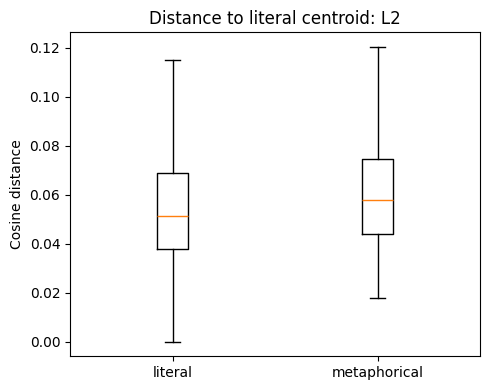

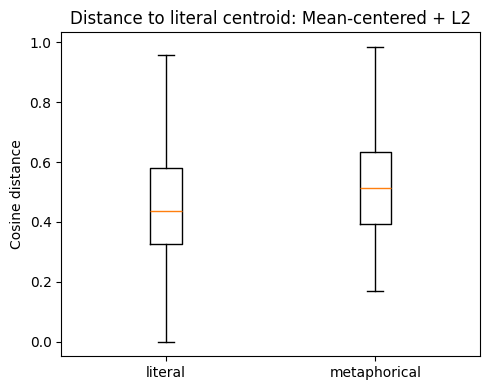

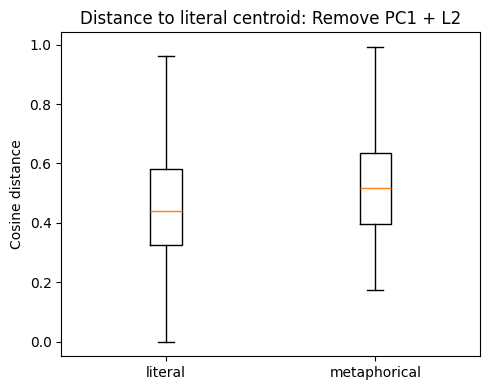

In [20]:
plot_df = pd.concat([
    dfd.assign(setting=name) for name, dfd in distance_dfs.items()
], ignore_index=True)
plot_df["label_name"] = plot_df["label_bin"].map({0:"literal", 1:"metaphorical"})

settings = list(vector_settings.keys())
for setting in settings:
    tmp = plot_df[plot_df["setting"] == setting].dropna(subset=["dist_to_literal_centroid"])
    data = [
        tmp[tmp["label_name"] == "literal"]["dist_to_literal_centroid"].values,
        tmp[tmp["label_name"] == "metaphorical"]["dist_to_literal_centroid"].values,
    ]
    plt.figure(figsize=(5,4))
    plt.boxplot(data, labels=["literal", "metaphorical"], showfliers=False)
    plt.title(f"Distance to literal centroid: {setting}")
    plt.ylabel("Cosine distance")
    plt.tight_layout()
    fname = f"distance_boxplot_{setting.replace(' ', '_').replace('+','plus')}.png"
    plt.savefig(os.path.join(OUTPUT_DIR, fname), dpi=200)
    plt.show()

## 13. Experiment 2: Literal vs. metaphor centroid separation by lemma

This analysis asks which verbs show the clearest separation between literal and metaphorical usage centroids.


 L2


,lemma,n_literal,n_metaphorical,centroid_distance
79,grimace,1,1,0.170398
13,assemble,1,4,0.151793
5,activate,1,2,0.134843
136,register,3,1,0.120594
153,shed,1,2,0.114455
131,rank,1,1,0.112631
104,march,1,1,0.105565
184,test,7,1,0.104613
160,smother,1,1,0.103853
100,loom,2,1,0.095626



 Mean-centered + L2


,lemma,n_literal,n_metaphorical,centroid_distance
13,assemble,1,4,1.025588
104,march,1,1,0.942823
61,enact,1,2,0.894698
129,question,2,1,0.886578
153,shed,1,2,0.875993
5,activate,1,2,0.871512
100,loom,2,1,0.870467
136,register,3,1,0.864062
193,unfold,2,1,0.839325
157,sing,8,1,0.813740



 Remove PC1 + L2


,lemma,n_literal,n_metaphorical,centroid_distance
13,assemble,1,4,1.055676
5,activate,1,2,0.971183
104,march,1,1,0.945052
129,question,2,1,0.910192
157,sing,8,1,0.896469
153,shed,1,2,0.886462
100,loom,2,1,0.870648
136,register,3,1,0.865559
88,interrupt,4,2,0.844532
193,unfold,2,1,0.841766


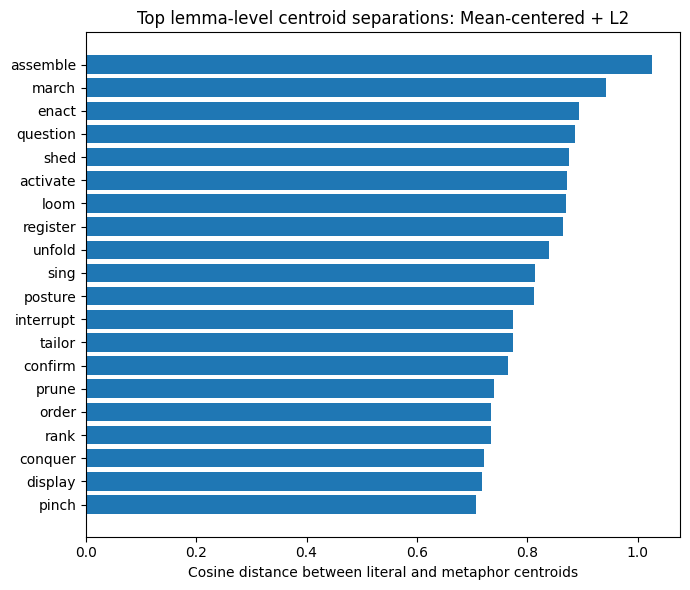

In [22]:
def compute_centroid_separation(df_in, X):
    rows = []
    # Use the index of the dataframe to slice X, assuming df_in index aligns with X rows
    # We don't reset_index() here to ensure we stay aligned with X's row positions
    for lemma, sub in df_in.groupby("lemma"):
        # Get the integer positions relative to df_in
        # This assumes df_in was reset when X was created (as in cell fdecec3e)
        lit_sub = sub[sub["label_bin"] == 0]
        met_sub = sub[sub["label_bin"] == 1]

        if len(lit_sub) == 0 or len(met_sub) == 0:
            continue

        # Use the integer-based indices to slice the numpy array X
        lit_idxs = lit_sub.index.tolist()
        met_idxs = met_sub.index.tolist()

        c_lit = X[lit_idxs].mean(axis=0)
        c_met = X[met_idxs].mean(axis=0)

        rows.append({
            "lemma": lemma,
            "n_literal": len(lit_idxs),
            "n_metaphorical": len(met_idxs),
            "centroid_distance": cosine_distance_vec(c_lit, c_met),
        })
    return pd.DataFrame(rows).sort_values("centroid_distance", ascending=False)

separation_tables = {}
for name, X in vector_settings.items():
    # df_embed was already reset_index(drop=True) in cell fdecec3e
    sep = compute_centroid_separation(df_embed, X)
    separation_tables[name] = sep
    sep.to_csv(os.path.join(OUTPUT_DIR, f"centroid_separation_{name.replace(' ', '_').replace('+','plus')}.csv"), index=False)
    print("\n", name)
    display(sep.head(15))

main_sep = separation_tables["Mean-centered + L2"].head(20).iloc[::-1]
plt.figure(figsize=(7,6))
plt.barh(main_sep["lemma"], main_sep["centroid_distance"])
plt.title("Top lemma-level centroid separations: Mean-centered + L2")
plt.xlabel("Cosine distance between literal and metaphor centroids")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "top_centroid_separations.png"), dpi=200)
plt.show()

## 14. Experiment 3: Classification sanity check

This baseline asks whether target-token embeddings contain metaphor-relevant signal.

To reduce lexical memorization, the split is grouped by lemma: the same lemma should not appear in both train and test within a split.

In [23]:
def evaluate_classifiers_for_setting(df_in, X, setting_name, n_splits=5):
    y = df_in["label_bin"].astype(int).values
    groups = df_in["lemma"].values

    splitter = GroupShuffleSplit(n_splits=n_splits, test_size=0.25, random_state=SEED)

    clf_defs = {
        "Logistic Regression": make_pipeline(
            StandardScaler(),
            LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
        ),
        "Linear SVM": make_pipeline(
            StandardScaler(),
            LinearSVC(class_weight="balanced", random_state=SEED)
        ),
    }

    rows = []
    preds_store = {}

    for split_id, (train_idx, test_idx) in enumerate(splitter.split(X, y, groups=groups)):
        for clf_name, clf in clf_defs.items():
            clf.fit(X[train_idx], y[train_idx])
            pred = clf.predict(X[test_idx])

            acc = accuracy_score(y[test_idx], pred)
            p, r, f1, _ = precision_recall_fscore_support(y[test_idx], pred, average="binary", zero_division=0)
            p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y[test_idx], pred, average="macro", zero_division=0)
            majority_acc = max(np.mean(y[test_idx] == 0), np.mean(y[test_idx] == 1))

            rows.append({
                "setting": setting_name,
                "classifier": clf_name,
                "split": split_id,
                "accuracy": acc,
                "precision_metaphor": p,
                "recall_metaphor": r,
                "f1_metaphor": f1,
                "macro_f1": f1_macro,
                "majority_baseline_accuracy": majority_acc,
                "n_train": len(train_idx),
                "n_test": len(test_idx),
                "test_lemmas": len(set(groups[test_idx])),
            })

            preds_store[(setting_name, clf_name, split_id)] = {
                "test_idx": test_idx,
                "y_true": y[test_idx],
                "y_pred": pred,
            }

    return pd.DataFrame(rows), preds_store

clf_rows = []
all_preds = {}

for name, X in vector_settings.items():
    res, preds = evaluate_classifiers_for_setting(df_embed, X, name)
    clf_rows.append(res)
    all_preds.update(preds)

clf_results = pd.concat(clf_rows, ignore_index=True)
display(clf_results.groupby(["setting", "classifier"])[["accuracy", "f1_metaphor", "macro_f1", "majority_baseline_accuracy"]].agg(["mean", "std"]))
clf_results.to_csv(os.path.join(OUTPUT_DIR, "classification_results_by_split.csv"), index=False)

accuracy           f1_metaphor  \
                                            mean       std        mean   
setting            classifier                                            
L2                 Linear SVM           0.595429  0.045668    0.554779   
                   Logistic Regression  0.602609  0.040845    0.557908   
Mean-centered + L2 Linear SVM           0.595164  0.047882    0.552510   
                   Logistic Regression  0.599760  0.035842    0.555605   
Remove PC1 + L2    Linear SVM           0.600141  0.044657    0.554437   
                   Logistic Regression  0.597122  0.035978    0.550617   

                                                  macro_f1            \
                                             std      mean       std   
setting            classifier                                          
L2                 Linear SVM           0.052273  0.591181  0.046180   
                   Logistic Regression  0.047785  0.597435  0.040969   
Mean-centered + L2 Linear SVM           0.059790  0.590501  0.049123   
                   Logistic Regression  0.045141  0.594584  0.036108   
Remove PC1 + L2    Linear SVM           0.054597  0.595021  0.045481   
                   Logistic Regression  0.045224  0.591785  0.036360   

                                       majority_baseline_accuracy            
                                                             mean       std  
setting            classifier                                                
L2                 Linear SVM                            0.556351  0.023155  
                   Logistic Regression                   0.556351  0.023155  
Mean-centered + L2 Linear SVM                            0.556351  0.023155  
                   Logistic Regression                   0.556351  0.023155  
Remove PC1 + L2    Linear SVM                            0.556351  0.023155  
                   Logistic Regression                   0.556351  0.023155

## 15. Plot classification results and test whether anisotropy reduction improves performance

The paired test compares per-split macro-F1 between `L2` and the setting that most reduces anisotropy according to mean pairwise cosine.

,setting,classifier,macro_f1_mean,macro_f1_std,acc_mean
0,L2,Linear SVM,0.591181,0.046180,0.595429
1,L2,Logistic Regression,0.597435,0.040969,0.602609
2,Mean-centered + L2,Linear SVM,0.590501,0.049123,0.595164
3,Mean-centered + L2,Logistic Regression,0.594584,0.036108,0.599760
4,Remove PC1 + L2,Linear SVM,0.595021,0.045481,0.600141
5,Remove PC1 + L2,Logistic Regression,0.591785,0.036360,0.597122


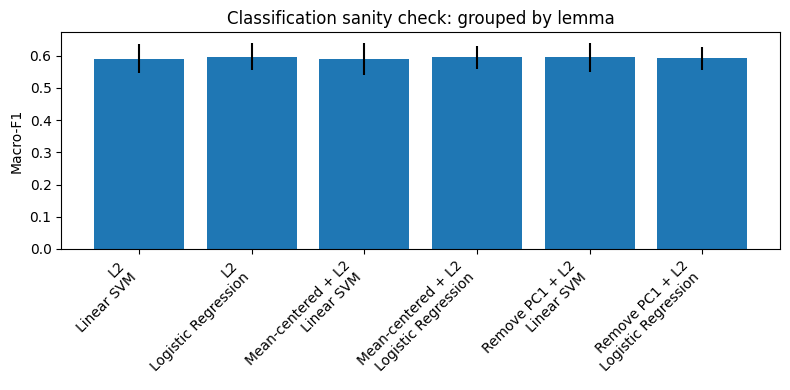

Setting with lowest mean pairwise cosine: Remove PC1 + L2


,classifier,comparison,mean_macro_f1_difference,wilcoxon_statistic,wilcoxon_p
0,Logistic Regression,Remove PC1 + L2 minus L2,-0.005651,3.0,0.3125
1,Linear SVM,Remove PC1 + L2 minus L2,0.003840,6.0,0.8125


In [24]:
agg = clf_results.groupby(["setting", "classifier"], as_index=False).agg(
    macro_f1_mean=("macro_f1", "mean"),
    macro_f1_std=("macro_f1", "std"),
    acc_mean=("accuracy", "mean")
)
display(agg)

plt.figure(figsize=(8,4))
labels = agg["setting"] + "\n" + agg["classifier"]
plt.bar(labels, agg["macro_f1_mean"], yerr=agg["macro_f1_std"])
plt.title("Classification sanity check: grouped by lemma")
plt.ylabel("Macro-F1")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "classification_macro_f1.png"), dpi=200)
plt.show()

# Choose the processed setting with lowest mean pairwise cosine, excluding Raw.
anis_no_raw = anis_df[anis_df["setting"] != "Raw"].copy()
best_aniso_setting = anis_no_raw.sort_values("mean_pairwise_cosine").iloc[0]["setting"]
print("Setting with lowest mean pairwise cosine:", best_aniso_setting)

improvement_rows = []
for clf_name in clf_results["classifier"].unique():
    base = clf_results[(clf_results["setting"] == "L2") & (clf_results["classifier"] == clf_name)].sort_values("split")
    best = clf_results[(clf_results["setting"] == best_aniso_setting) & (clf_results["classifier"] == clf_name)].sort_values("split")
    if len(base) == len(best) and len(base) > 1:
        diff = best["macro_f1"].values - base["macro_f1"].values
        try:
            stat, p = wilcoxon(diff)
        except Exception:
            stat, p = np.nan, np.nan
        improvement_rows.append({
            "classifier": clf_name,
            "comparison": f"{best_aniso_setting} minus L2",
            "mean_macro_f1_difference": float(np.mean(diff)),
            "wilcoxon_statistic": float(stat) if not np.isnan(stat) else np.nan,
            "wilcoxon_p": float(p) if not np.isnan(p) else np.nan,
        })

improvement_df = pd.DataFrame(improvement_rows)
display(improvement_df)
improvement_df.to_csv(os.path.join(OUTPUT_DIR, "anisotropy_reduction_classification_improvement.csv"), index=False)

## 16. Optional qualitative visualization: PCA plot for selected lemmas

This visualization is not used as main evidence. It is only a qualitative sanity check.

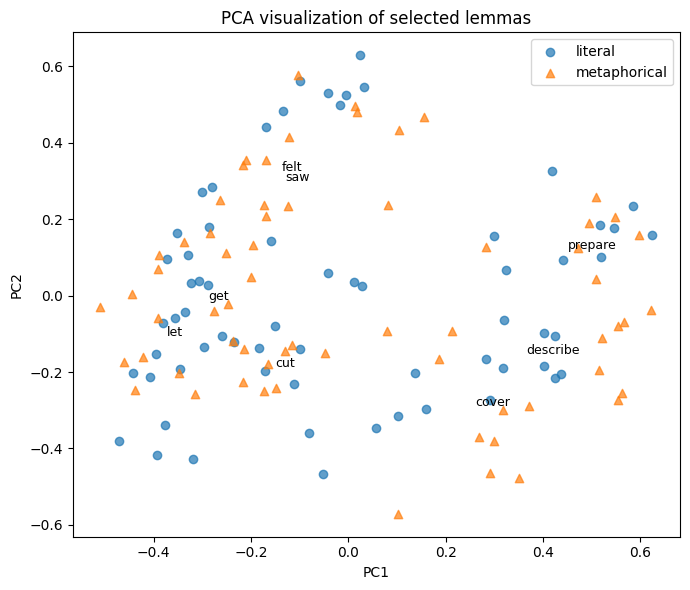

In [25]:
# Select frequent lemmas for a readable plot.
top_lemmas = df_embed["lemma"].value_counts().head(8).index.tolist()
mask = df_embed["lemma"].isin(top_lemmas).values

X_vis = vector_settings["Mean-centered + L2"][mask]
df_vis = df_embed[mask].copy().reset_index(drop=True)

pca2 = PCA(n_components=2, random_state=SEED)
coords = pca2.fit_transform(X_vis)

plt.figure(figsize=(7,6))
for label, marker in [(0, "o"), (1, "^")]:
    m = df_vis["label_bin"].values == label
    plt.scatter(coords[m,0], coords[m,1], alpha=0.7, marker=marker, label={0:"literal",1:"metaphorical"}[label])

for lemma in top_lemmas:
    m = df_vis["lemma"].values == lemma
    if m.sum() > 0:
        plt.text(coords[m,0].mean(), coords[m,1].mean(), lemma, fontsize=9)

plt.title("PCA visualization of selected lemmas")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "pca_selected_lemmas.png"), dpi=200)
plt.show()

## 17. Save all key outputs

The output directory contains tables and figures for the report.

In [26]:
print("Output directory:", OUTPUT_DIR)
print(os.listdir(OUTPUT_DIR))

Output directory: /content/metaphor_mvp_outputs
['distance_boxplot_Mean-centered_plus_L2.png', 'centroid_separation_Remove_PC1_plus_L2.csv', 'pca_selected_lemmas.png', 'label_distribution.png', 'pc1_by_label.png', 'distance_boxplot_Remove_PC1_plus_L2.png', 'anisotropy_metrics.csv', 'centroid_separation_L2.csv', 'anisotropy_mean_cosine.png', 'anisotropy_pc1.png', 'centroid_separation_Mean-centered_plus_L2.csv', 'distance_boxplot_L2.png', 'pc1_vs_sentence_length.png', 'sampled_vua20_verbs.csv', 'literal_centroid_distance_summary.csv', 'classification_macro_f1.png', 'top_centroid_separations.png', 'anisotropy_factor_correlations.csv', 'anisotropy_reduction_classification_improvement.csv', 'classification_results_by_split.csv']


## 18. MVP conclusion and analysis


### Overall Conclusion

The MVP provides **weak-to-moderate support** for the contextual embedding shift hypothesis: metaphorical verb usages are, on average, farther from their lemma-specific literal centroids than literal usages. However, the effect is not strong enough to claim that metaphor can be directly reduced to embedding distance, and classification performance remains only slightly above the majority baseline.

---

### 1. Dataset and Scope

The MVP used **VUA20 verb instances** only.

| Item | Value |
|---|---:|
| Total verb subset | 24,930 |
| Literal verbs | 18,703 |
| Metaphorical verbs | 6,227 |
| Eligible lemmas with both labels | 784 |
| Selected lemmas | 200 |
| Sampled rows | 1,605 |
| Literal sampled rows | 898 |
| Metaphorical sampled rows | 707 |

This is a valid Scope 1 setup because it focuses on **within-lemma literal/metaphorical contrast**, not global metaphor detection.

---

### 2. Exp 1: Literal Centroid Distance

The main hypothesis was supported across all representation settings.

| Setting | Literal mean | Metaphorical mean | Gap | p-value | Cohen's d |
|---|---:|---:|---:|---:|---:|
| L2 | 0.0549 | 0.0621 | 0.0072 | 2.45e-07 | 0.258 |
| Mean-centered + L2 | 0.4508 | 0.5260 | 0.0751 | 8.77e-15 | 0.387 |
| Remove PC1 + L2 | 0.4600 | 0.5331 | 0.0731 | 1.28e-13 | 0.369 |

**Interpretation:** metaphorical usages are significantly farther from literal centroids, but the effect size is small to moderate. This supports the **geometric tendency**, not a full theory of metaphor.

---

### 3. Exp 2: Centroid Separation by Lemma

Some lemmas showed clear literal/metaphorical centroid separation, but many top-ranked examples had very small sample sizes, such as **1 literal vs. 1 metaphorical** instance.

**Interpretation:** this experiment is useful for qualitative error analysis, but the current lemma ranking should not be treated as stable lexical evidence unless a minimum sample threshold is added, such as:

```text
n_literal >= 3 and n_metaphorical >= 3
```

or preferably:

```text
n_literal >= 5 and n_metaphorical >= 5
```

---

### 4. Exp 3: Classification Sanity Check

Classification was only slightly above the majority baseline.

| Setting | Classifier | Accuracy | Macro-F1 | Metaphor F1 | Majority baseline |
|---|---|---:|---:|---:|---:|
| L2 | Logistic Regression | 0.603 | 0.597 | 0.558 | 0.556 |
| L2 | Linear SVM | 0.595 | 0.591 | 0.555 | 0.556 |
| Mean-centered + L2 | Logistic Regression | 0.600 | 0.595 | 0.556 | 0.556 |
| Remove PC1 + L2 | Logistic Regression | 0.597 | 0.592 | 0.551 | 0.556 |

**Interpretation:** RoBERTa target-token embeddings contain metaphor-relevant signal, but this signal is weak under grouped-by-lemma generalization.

---

### 5. Exp 5: Anisotropy Robustness

Anisotropy was clearly present in raw RoBERTa embeddings.

| Setting | Mean pairwise cosine | Anisotropy score | PC1 variance ratio |
|---|---:|---:|---:|
| Raw | 0.8570 | 0.9285 | 0.0759 |
| L2 | 0.8570 | 0.9285 | 0.0742 |
| Mean-centered + L2 | 0.0016 | 0.5008 | 0.0701 |
| Remove PC1 + L2 | 0.0007 | 0.5004 | 0.0466 |

However, anisotropy reduction did **not** significantly improve classification.

| Classifier | Comparison | Macro-F1 difference | p-value |
|---|---|---:|---:|
| Logistic Regression | Remove PC1 + L2 − L2 | -0.0057 | 0.3125 |
| Linear SVM | Remove PC1 + L2 − L2 | +0.0038 | 0.8125 |

**Interpretation:** anisotropy correction improves geometric interpretability, but it is not a reliable performance booster for metaphor classification.